# 独立 RGB Mask 可视化

输入仅为有水印 RGB 图，输出单通道水印 Mask。

In [ ]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch.nn import functional as F
from torch.utils.data import DataLoader

MODEL_DIR = Path.cwd().resolve()
if not (MODEL_DIR / 'models/network.py').exists():
    MODEL_DIR = MODEL_DIR / 'mask-model'
if not (MODEL_DIR / 'models/network.py').exists():
    raise FileNotFoundError('Please run this notebook from the project root or mask-model directory')
sys.path.insert(0, str(MODEL_DIR))

import models.network as model_module
model_module = importlib.reload(model_module)
WatermarkMaskNet = model_module.WatermarkMaskNet
import train as train_module
train_module = importlib.reload(train_module)
CLWDDataset = train_module.CLWDDataset

PROJECT_DIR = MODEL_DIR.parent
TEST_ROOT = PROJECT_DIR / '0-数据/data（CLWD 格式）/clwd_crop/test'
CHECKPOINT = MODEL_DIR / 'weights/watermark_mask.pt'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_SIZE = 512
THRESHOLD = 0.5
NUM_SAMPLES = 6
print(f'model_dir={MODEL_DIR}')
print(f'checkpoint={CHECKPOINT}')
print(f'device={DEVICE}')

model_dir=./mask-model
checkpoint=./mask-model/weights/watermark_mask.pt
device=cuda


In [2]:
checkpoint = torch.load(CHECKPOINT, map_location='cpu', weights_only=False)
model = WatermarkMaskNet(pretrained=False).to(DEVICE).eval()
weights = checkpoint.get('model', checkpoint)
current = model.state_dict()
compatible = {name: value for name, value in weights.items() if name in current and current[name].shape == value.shape}
model.load_state_dict(compatible, strict=False)
parameters = sum(parameter.numel() for parameter in model.parameters())
print(f"checkpoint_epoch={checkpoint.get('epoch', 'weights-only')} parameters={parameters:,}")
print(f"recorded_best_iou={checkpoint.get('best_iou', 'n/a')} transferred={len(compatible)}/{len(current)}")

checkpoint_epoch=17 parameters=3,083,107
recorded_best_iou=0.7929976533311951 transferred=420/420


## 512 测试裁块

从固定验证裁块中选取包含水印的样本，保证多次运行选中的样本一致。

In [3]:
test_data = CLWDDataset(TEST_ROOT, IMAGE_SIZE, training=False, candidate_input=False)
rng = np.random.default_rng(2026)
sample_indices = []
for index in rng.permutation(len(test_data)):
    _, target = test_data[int(index)]
    if target[0].sum() > 0:
        sample_indices.append(int(index))
    if len(sample_indices) == NUM_SAMPLES:
        break

images, targets = zip(*(test_data[index] for index in sample_indices))
image_batch = torch.stack(images).to(DEVICE)
target_batch = torch.stack(targets)
with torch.inference_mode(), torch.autocast(DEVICE.type, enabled=DEVICE.type == 'cuda', dtype=torch.float16):
    prediction_batch = model(image_batch).sigmoid().cpu()
print('sample_indices=', sample_indices)

sample_indices= [1222, 1250, 735, 1640, 399, 651]


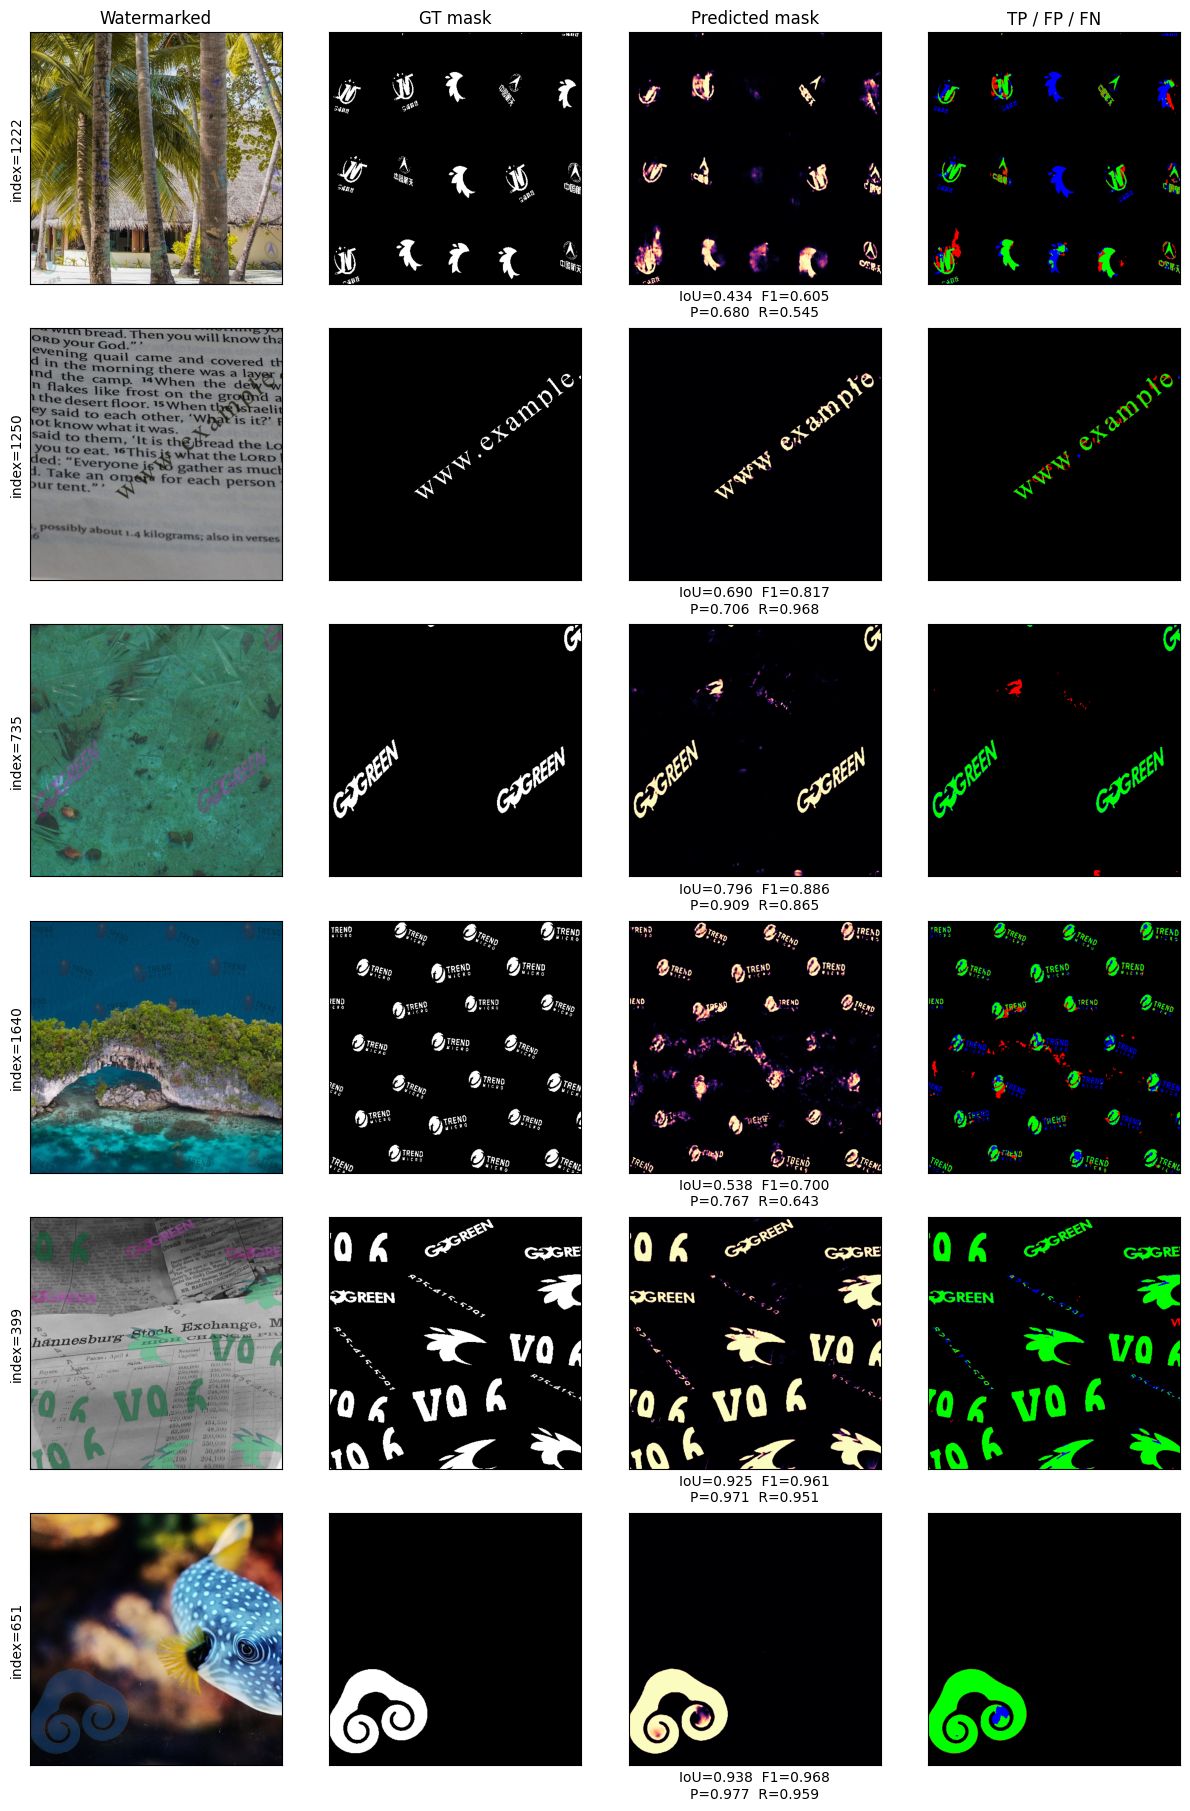

In [4]:
def sample_metrics(mask_probability, truth, threshold=0.5):
    predicted = mask_probability >= threshold
    truth = truth >= 0.5
    tp = (predicted & truth).sum().item()
    fp = (predicted & ~truth).sum().item()
    fn = (~predicted & truth).sum().item()
    union = tp + fp + fn
    iou = tp / union if union else 1.0
    precision = tp / (tp + fp) if tp + fp else 1.0
    recall = tp / (tp + fn) if tp + fn else 1.0
    f1 = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 1.0
    return iou, f1, precision, recall

figure, axes = plt.subplots(NUM_SAMPLES, 4, figsize=(12, 3 * NUM_SAMPLES), constrained_layout=True)
columns = ['Watermarked', 'GT mask', 'Predicted mask', 'TP / FP / FN']
for axis, title in zip(axes[0], columns):
    axis.set_title(title)

for row, (image, target, prediction, index) in enumerate(zip(images, targets, prediction_batch, sample_indices)):
    rgb = image.permute(1, 2, 0).numpy()
    truth = target[0].numpy() >= 0.5
    mask_probability = prediction[0].numpy()
    predicted = mask_probability >= THRESHOLD
    error = np.zeros((*truth.shape, 3), dtype=np.float32)
    error[..., 1] = predicted & truth       # TP: green
    error[..., 0] = predicted & ~truth      # FP: red
    error[..., 2] = ~predicted & truth      # FN: blue
    metrics = sample_metrics(prediction[0], target[0], THRESHOLD)

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_ylabel(f'index={index}')
    axes[row, 1].imshow(truth, cmap='gray', vmin=0, vmax=1)
    axes[row, 2].imshow(mask_probability, cmap='magma', vmin=0, vmax=1)
    axes[row, 2].set_xlabel(f'IoU={metrics[0]:.3f}  F1={metrics[1]:.3f}\nP={metrics[2]:.3f}  R={metrics[3]:.3f}')
    axes[row, 3].imshow(error)
    for axis in axes[row]:
        axis.set_xticks([])
        axis.set_yticks([])
plt.show()

## 完整验证集指标（可选）

将 `RUN_FULL_EVAL` 改为 `True` 可在全部 1,899 个固定裁块上计算聚合指标。

In [5]:
RUN_FULL_EVAL = False
if RUN_FULL_EVAL:
    loader = DataLoader(test_data, batch_size=12, shuffle=False, num_workers=0, pin_memory=True)
    tp = fp = fn = 0
    with torch.inference_mode():
        for image, target in loader:
            image = image.to(DEVICE, non_blocking=True)
            with torch.autocast(DEVICE.type, enabled=DEVICE.type == 'cuda', dtype=torch.float16):
                prediction = model(image).sigmoid().cpu()
            predicted = prediction[:, :1] >= THRESHOLD
            truth = target[:, :1] >= 0.5
            tp += (predicted & truth).sum().item()
            fp += (predicted & ~truth).sum().item()
            fn += (~predicted & truth).sum().item()
    print({
        'IoU': tp / (tp + fp + fn),
        'F1': 2 * tp / (2 * tp + fp + fn),
        'Precision': tp / (tp + fp),
        'Recall': tp / (tp + fn),
    })
else:
    print('Full evaluation skipped. Set RUN_FULL_EVAL=True to run it.')

Full evaluation skipped. Set RUN_FULL_EVAL=True to run it.


## 原始分辨率滑窗推理

默认使用 CLWD test 的第一张有水印图。测试线上数据时，将 `CUSTOM_IMAGE` 指向有水印图。

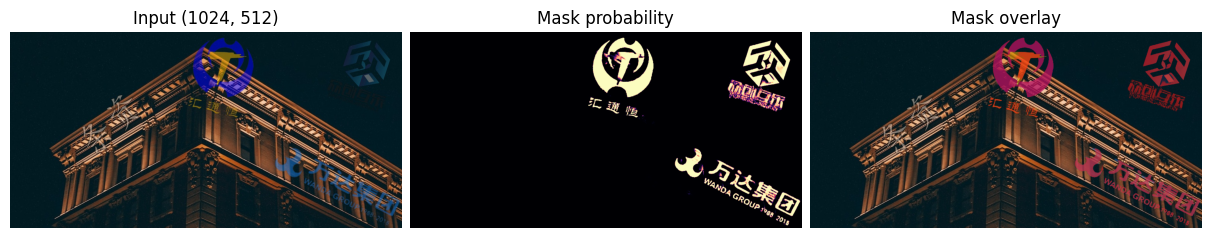

custom_image= <your-image-path>
input_size= (1024, 512) prediction_size= (1024, 512)


In [ ]:
def tile_starts(length, tile, overlap):
    if length <= tile:
        return [0]
    starts = list(range(0, length - tile + 1, tile - overlap))
    if starts[-1] != length - tile:
        starts.append(length - tile)
    return starts

@torch.inference_mode()
def predict_full_resolution(pil_image, tile=512, overlap=64):
    array = np.asarray(pil_image.convert('RGB'), dtype=np.float32) / 255.0
    tensor = torch.from_numpy(array.copy()).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    original_height, original_width = tensor.shape[-2:]
    pad_height = max(0, tile - original_height)
    pad_width = max(0, tile - original_width)
    tensor = F.pad(tensor, (0, pad_width, 0, pad_height), mode='replicate')
    height, width = tensor.shape[-2:]
    accumulator = torch.zeros((1, 1, height, width), device=DEVICE)
    divisor = torch.zeros((1, 1, height, width), device=DEVICE)
    window_1d = torch.hann_window(tile, periodic=False, device=DEVICE).clamp_min(1e-3)
    window = (window_1d[:, None] * window_1d[None, :])[None, None]
    for top in tile_starts(height, tile, overlap):
        for left in tile_starts(width, tile, overlap):
            patch = tensor[:, :, top:top + tile, left:left + tile]
            with torch.autocast(DEVICE.type, enabled=DEVICE.type == 'cuda', dtype=torch.float16):
                probability = model(patch).sigmoid()
            accumulator[:, :, top:top + tile, left:left + tile] += probability * window
            divisor[:, :, top:top + tile, left:left + tile] += window
    result = accumulator / divisor.clamp_min(1e-6)
    return result[0, :, :original_height, :original_width].float().cpu().numpy()

custom_candidates = sorted((TEST_ROOT / 'Watermarked_image').glob('*'))
CUSTOM_IMAGE = custom_candidates[15]
custom_image = Image.open(CUSTOM_IMAGE).convert('RGB')
custom_prediction = predict_full_resolution(custom_image)
custom_rgb = np.asarray(custom_image, dtype=np.float32) / 255.0
custom_mask = custom_prediction[0]
overlay = custom_rgb.copy()
strength = 0.55 * custom_mask[..., None]
overlay = np.clip(overlay * (1 - strength) + np.array([1.0, 0.1, 0.1]) * strength, 0, 1)

figure, axes = plt.subplots(1, 3, figsize=(12, 5), constrained_layout=True)
for axis, content, title, cmap in zip(
    axes,
    [custom_rgb, custom_mask, overlay],
    [f'Input {custom_image.size}', 'Mask probability', 'Mask overlay'],
    [None, 'magma', None],
):
    axis.imshow(content, cmap=cmap, vmin=0 if cmap else None, vmax=1 if cmap else None)
    axis.set_title(title)
    axis.axis('off')
plt.show()
print('custom_image=', CUSTOM_IMAGE)
print('input_size=', custom_image.size, 'prediction_size=', (custom_prediction.shape[2], custom_prediction.shape[1]))